<a href="https://colab.research.google.com/github/priyav23116/sentiment-analysis-using-deep-learning-/blob/main/Copy_of_Copy_of_Sentiment_analysis_using_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 91s 553ms/step - accuracy: 0.7789 - loss: 0.4612 - val_accuracy: 0.8454 - val_loss: 0.3748
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 505ms/step - accuracy: 0.8971 - loss: 0.2629 - val_accuracy: 0.8688 - val_loss: 0.3068
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 73s 462ms/step - accuracy: 0.9316 - loss: 0.1849 - val_accuracy: 0.8678 - val_loss: 0.3217
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8702 - loss: 0.3367

Test Accuracy: 0.8702399730682373


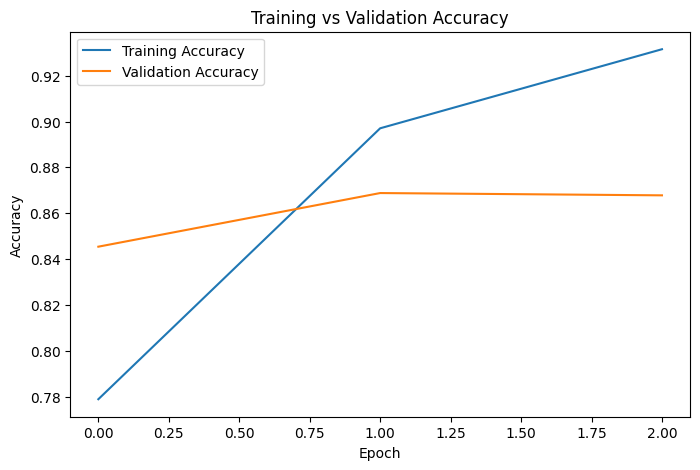

Model saved as sentiment_model.h5
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step

Review: this movie was amazing and i loved it
Sentiment: Positive 😊


In [1]:
Xx ee# Sentiment Analysis Using Deep Learning

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

# Load IMDB dataset
max_features = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Build LSTM Model
model = Sequential([
    Embedding(max_features, 128),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", accuracy)

# Plot Training Curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Save Model
model.save("sentiment_model.h5")
print("Model saved as sentiment_model.h5")

# Sentiment Prediction Example
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = [word_index.get(word, 2) for word in words]
    return pad_sequences([encoded], maxlen=maxlen)

review = "this movie was amazing and i loved it"

encoded_review = encode_review(review)

prediction = model.predict(encoded_review)

print("\nReview:", review)

if prediction[0][0] > 0.5:
    print("Sentiment: Positive ")
else:
    print("Sentiment: Negative ")